This notebook is to demonstrate partly the general feeling of unrest the majority of British people feel towards rising prices and looks at it through the lens of housing costs. It aims to to provide graphical and numerical comfirmation to the cost of living crisis and# suggests as to where it comes from.

In [1]:
#Load the data of average housing costs, salary and inflation.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Housing_df = pd.read_csv("Data/ukhpi-property-type-avg-united-kingdom-from-2000-01-01-to-2026-04-01.csv")
Wage_df = pd.read_csv("Data/emp.csv")

In [2]:
#test what the data looks like
print([cols for cols in Wage_df.columns if "AWE" in cols])

['AWE: Whole Economy Real Terms Index: Seasonally Adjusted Regular Pay', 'AWE: Whole Economy Real Terms Year on Year Single Month Growth (%): Seasonally Adjusted Regular Pay', 'AWE: Whole Economy Real Terms Year on Year three Month Growth (%): Seasonally Adjusted Regular Pay', 'AWE: Whole Economy Real Terms Level (£): Seasonally Adjusted Regular Pay', 'AWE: Whole Economy Real Terms Index: Seasonally Adjusted Total Pay', 'AWE: Whole Economy Real Terms Year on Year Single Month Growth (%): Seasonally Adjusted Total Pay', 'AWE: Whole Economy Real Terms Year on Year Three Month Growth (%): Seasonally Adjusted Total Pay', 'AWE: Whole Economy Real Terms Level (£): Seasonally Adjusted Total Pay', 'AWE: Whole Economy Year on Year Single Month Growth (%): Non Seasonally Adjusted Total Pay Excluding Arrears', 'AWE: Manufacturing Year on Year Single Month Growth (%): Non Seasonally Adjusted Total Pay Excluding Arrears', 'AWE: Construction Year on Year Single Month Growth (%): Non Seasonally Adjus

In [3]:
#Clean data

#housing costs: require little cleaning just standardise the date
Housing_df["Date"] = pd.to_datetime(Housing_df["Period"], format="%Y-%m")
Housing_df = Housing_df.rename(columns=
    {'Average price All property types':"AvgPrice"} #We will look broadly at all property types
    )
#print(Housing_df[["Date", "AvgPrice"]].head())

#Wage: focus on average weekly real gross regular pay (£), gives it in monthly increments but contains lots of filler
AWE_df = Wage_df.copy()
AWE_df = AWE_df.rename(columns=
    {
        "AWE: Whole Economy Real Terms Level (£): Seasonally Adjusted Regular Pay":"AWE",
        "Title":"Date"
     } 
    ) 
#print(AWE_df)

idx = AWE_df[AWE_df["Date"] == "2000 JAN"].index.to_numpy()[0] #Since df is ordered can parse using index of date name
AWE_df = AWE_df.iloc[idx:]
#print(AWE_df)

AWE_df['Date'] = pd.to_datetime(AWE_df["Date"], format='%Y %b') #convert to datetime
#print(AWE_df[["Date","AWE"]])


I have come to realise a problem in comparing these datasets, in that the earnings are in real terms while the HPI uses nominal values. If compared as is, the discrepency in the ratio between wages and housing price will be grossly oversestimated and would harm the integrity of this study. Two options come naturally; convert earnings to nominal values using an index such as CPI, or convert house prices to real terms using housing inflation values. The former seems the obvious choice as the CPI is well documented and is most relevant to the demographic of average earnings. The latter choice also proves more complex, as methods of calculating housing inflation, such as hedonic regression, is beyond this analysis projects scope for now.

In [4]:
#Download and clean inflation data 
CPIH_df = pd.read_csv("Data/series-300526.csv")
Inf_df = CPIH_df.copy()
Inf_df = Inf_df.rename(columns=
    {"Title":"Date"} 
    ) 

#similar cleaning process to the wage df, remove initial filler using index of "2000 JAN" to parse
idx = Inf_df[Inf_df["Date"] == "2000 JAN"].index.to_numpy()[0] #Since df is ordered can parse using index of date name
Inf_df = Inf_df.iloc[idx:]
#print(Inf_df)

Inf_df['Date'] = pd.to_datetime(Inf_df["Date"], format='%Y %b') #convert to datetime
print(Inf_df)

          Date CPIH INDEX 00: ALL ITEMS 2015=100
342 2000-01-01                              72.6
343 2000-02-01                              72.8
344 2000-03-01                              73.0
345 2000-04-01                              73.3
346 2000-05-01                              73.5
..         ...                               ...
653 2025-12-01                             139.9
654 2026-01-01                             139.4
655 2026-02-01                             140.0
656 2026-03-01                             140.8
657 2026-04-01                             141.8

[316 rows x 2 columns]


In [5]:
#Use CPIH data to find nominal wages (base index for both: 2015=100)
CPIH = "CPIH INDEX 00: ALL ITEMS 2015=100" #make column name easier to find

AWE_Inf_df = AWE_df.join(Inf_df.set_index('Date'), on='Date')
#print(AWE_Inf_df["AWE"])

AWE_Inf_df['Nominal Wages'] = AWE_Inf_df["AWE"].astype(float) * (AWE_Inf_df[CPIH].astype(float) / 100)
#print(AWE_Inf_df[['Date','Nominal Wages']])

In [6]:
#Find min and max AWE to judge the tax rates needed to be implemented
#print(AWE_Inf_df["Nominal Wages"])
print(AWE_Inf_df["Nominal Wages"].max() * 52)
print(AWE_Inf_df["Nominal Wages"].min() * 52)

36022.272000000004
15214.055999999999


In [7]:
#Download tax data and clean accordingly

#Income tax rates require most care as there are multiple bands to keep in mind of 
#N/A to higher rate but rather the basic rate and pre 2008 the starting rate
IT = pd.read_excel("Data/Table_a2_-_Income_Tax_-_rates_and_allowances.ods")

IT = IT.rename( #Rename columns for clarity (Starting and Basic rates only apply)
    columns={
        "Table A.2 Rates of Income Tax between 1990 to 1991 and 2025 to 2026":'Date',
        "Unnamed: 3":"SR Band",
        "Unnamed: 4":"SR",
        "Unnamed: 5":"BR Band",
        "Unnamed: 6":"BR"
        }
        )
IT = IT[["Date","SR Band","SR","BR Band","BR"]] #cut irrelevant columns

idx = IT[IT["Date"] == "2000 to 2001"].index.to_numpy()[0] #change to relevant date and datatype
IT = IT.iloc[idx:-1] #-1 to get rid of end text
IT["Date"] = IT["Date"].apply(lambda x:pd.to_datetime(x[0:4], format="%Y"))

IT["BR"] = IT["BR"].apply(lambda x: int(x[0:2])) #get rid of footnotes 

IT["SR Band"] = IT["SR Band"].apply( #converts bands to list format for easier analysis
    lambda x: list(map(int,str(x).replace(",","").split("to"))) if not pd.isna(x) else x
    )
IT["BR Band"] = IT["BR Band"].apply( #converts bands to list format for easier analysis
    lambda x: list(map(int,str(x).replace(",","").split("to"))) if not pd.isna(x) else x
    )

IT["BR"] = IT["BR"] / 100 #conver percentages to decimal values
IT["SR"] = IT["SR"] / 100

#print(IT)

#======================================================================================================
#Personal Allowances are simpler only dealing with 
PA = pd.read_excel("Data/Table_a1_-_Income_Tax_-_personal_allowances_and_reliefs.ods")

PA = PA.rename( #rename relevant columns
    columns={
        "Table A.1 Income Tax Personal Allowances and Reliefs, between 1990 to 1991 and 2025 to 2026":'Date',
        "Unnamed: 1":"Personal Allowance",
        }
        )
PA = PA[["Date","Personal Allowance"]] #cut out irrelevant columns

idx = PA[PA["Date"] == "2000 to 2001"].index.to_numpy()[0] #change to relevant date and datatype
PA = PA.iloc[idx:-1] #-1 to get rid of end text 
PA["Date"] = PA["Date"].apply(lambda x:pd.to_datetime(x[0:4], format="%Y"))

PA["Personal Allowance"] = PA["Personal Allowance"].apply(      #get rid of footnotes and commas 
    lambda x:int(str(x)[:-8].replace(',','')) if type(x) is str else x  
    )

#print(PA)

#======================================================================================================
#NAtional Insurance is similar to PA but needs to be transposed 
#Additionally the NI contr between 2022-2024 fluctuated and is adressed accordingly
NI = pd.read_excel("Data/Table_a4_-_National_Insurance_Contributions_-_rates_and_allowances.ods")

NI = NI.transpose() #axis flipped (date as columns) so transpose required

NI = NI.rename(     #rename relevant columns
    columns={
        0:"Date",
        8:"NI contribution"
        }
        )

NI = NI[["Date", "NI contribution"]]    #cut out irrelevant columns

NI = NI.set_index(pd.Series(range(len(NI["Date"])))) #convert index to regular numerical index

idx = NI[NI["Date"] == "2000 to 2001"].index.to_numpy()[0] #change to relevant date and datatype
NI = NI.iloc[idx:-1] #-1 to get rid of end text 
NI["Date"] = NI["Date"].apply(lambda x:pd.to_datetime(x[0:4], format="%Y"))

#For 2022-2023 the NI contr was changed for half the year, so an average of the two will be taken, (0.1325 + 0.12)0.5 = 0.12625
#2023-2024 says the change from 12% to 10% happend in 2024 Jan, so we will assume 2023 was 12%
NI["NI contribution"] = NI["NI contribution"].replace({"13.25%/12% (note 16)":0.12625, "12%/10% (note 20)":0.12})
NI.loc[28] = [pd.to_datetime("2025"),0.08]

#print(NI)

In [8]:
#Merge columns together for ease of use, Also 2026 will assume the same tax code as 2025 
Tax_df = PA.merge(IT, on="Date")
Tax_df = Tax_df.merge(NI, on="Date")
 
Tax_df.loc[Tax_df.index[-1] + 1] = Tax_df.iloc[-1] #make a copy 
Tax_df.loc[Tax_df.index[-1], "Date"] = pd.to_datetime("2026")

#print(Tax_df)

To find net nominal pay we apply the tax codes appropriate for each year. This includes deducting personal allowance, then calculating the income tax band as well as taking off national insurance.

In [9]:
#Create a new column to get net yearly pay (after income tax and NI and deducting PA)
AWE_Inf_df["Avg Yearly Gross Pay"] = AWE_Inf_df["Nominal Wages"].astype(float) * 52
avg_yearly_gross = AWE_Inf_df[["Date", "Avg Yearly Gross Pay"]]
#print(avg_yearly_gross.shape)

#As this is a small dataset, I will take the cartesian product of the gross pay and tax datasets then filter the dates
NetPay_df = avg_yearly_gross.merge(Tax_df, how="cross", suffixes=("_pay","_tax")) #cartesian product
NetPay_df = NetPay_df[NetPay_df["Date_pay"].dt.year == NetPay_df["Date_tax"].dt.year] #apply a mask based on matching years
#print(NetPay_df)

NetPay_df["Taxable Income"] = NetPay_df["Avg Yearly Gross Pay"] - NetPay_df["Personal Allowance"] #minus PA 

#We can safely assume the Starting rate from 2000-2007 will apply to all yearly incomes
NetPay_df["SR deduction"] = NetPay_df["SR Band"].apply(lambda x: x[1] * 0.1 if type(x) is list else 0)

#Thus the rest of income tax deduction will be from basic rate deductions
NetPay_df["BR deduction"] = (NetPay_df["Taxable Income"] - NetPay_df["BR Band"].str[0]) * NetPay_df["BR"]

#NetPay_dfly is National Insurance which for the income range applies wholly over taxable income
NetPay_df["NI deduction"] = NetPay_df["Taxable Income"] * NetPay_df["NI contribution"]

#Thus we can now acquire average net yearly income (projected from weekly average incomes)
NetPay_df["Avg Yearly Net Pay"] = NetPay_df["Personal Allowance"] + NetPay_df["Taxable Income"] - NetPay_df["SR deduction"] -NetPay_df["BR deduction"] -NetPay_df["NI deduction"]
NetPay_df["Avg Yearly Net Pay"] = NetPay_df["Avg Yearly Net Pay"].apply(lambda x: round(x, 2)) #round to 2dp

print(NetPay_df[["Avg Yearly Net Pay", "Avg Yearly Gross Pay"]])

      Avg Yearly Net Pay  Avg Yearly Gross Pay
0               11931.38             15214.056
27              11959.88             15255.968
54              11936.75             15221.960
81              11979.29             15284.516
108             12059.63             15402.660
...                  ...                   ...
8395            29302.33             35809.072
8422            29447.19             36010.260
8450            29250.14             35736.584
8477            29360.89             35890.400
8504            29455.84             36022.272

[315 rows x 2 columns]


<Axes: xlabel='Date_pay', ylabel='Avg Yearly Net Pay'>

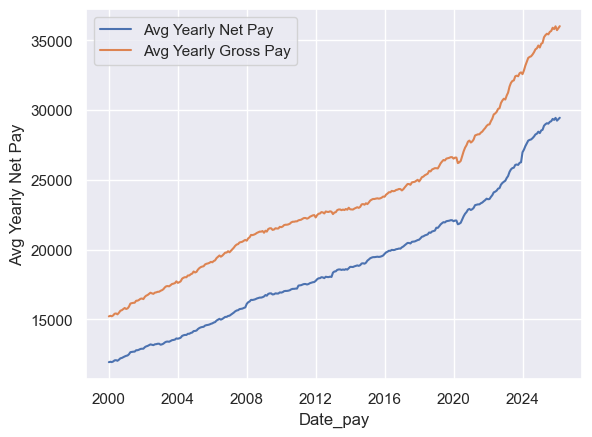

In [10]:
#Visualise the data/ sanity check
sns.set_theme()

sns.lineplot(data=NetPay_df, x="Date_pay", y = 'Avg Yearly Net Pay', label = 'Avg Yearly Net Pay')
sns.lineplot(data=NetPay_df, x="Date_pay", y = 'Avg Yearly Gross Pay', label = 'Avg Yearly Gross Pay')

In [ ]:
#Compare the salary growth with house price growth 
NetPay_df = NetPay_df.rename(columns={"Date_pay":"Date"}) #rename for merging purposes
final = NetPay_df.merge(Housing_df,on="Date") #merge housing price at each date
#print(final.head())

final["H to P Ratio"] = final["AvgPrice"] / final["Avg Yearly Net Pay"] #take ratio of house price to net pay


        Date  Avg Yearly Gross Pay   Date_tax  Personal Allowance    SR Band  \
0 2000-01-01             15214.056 2000-01-01                4385  [1, 1520]   
1 2000-02-01             15255.968 2000-01-01                4385  [1, 1520]   
2 2000-03-01             15221.960 2000-01-01                4385  [1, 1520]   
3 2000-04-01             15284.516 2000-01-01                4385  [1, 1520]   
4 2000-05-01             15402.660 2000-01-01                4385  [1, 1520]   

    SR        BR Band    BR NI contribution  Taxable Income  ...  \
0  0.1  [1521, 28400]  0.22             0.1       10829.056  ...   
1  0.1  [1521, 28400]  0.22             0.1       10870.968  ...   
2  0.1  [1521, 28400]  0.22             0.1       10836.960  ...   
3  0.1  [1521, 28400]  0.22             0.1       10899.516  ...   
4  0.1  [1521, 28400]  0.22             0.1       11017.660  ...   

   Region GSS code   Period Sales volume  Reporting period AvgPrice  \
0        K02000001  2000-01          Na

<Axes: xlabel='Date', ylabel='H to P Ratio'>

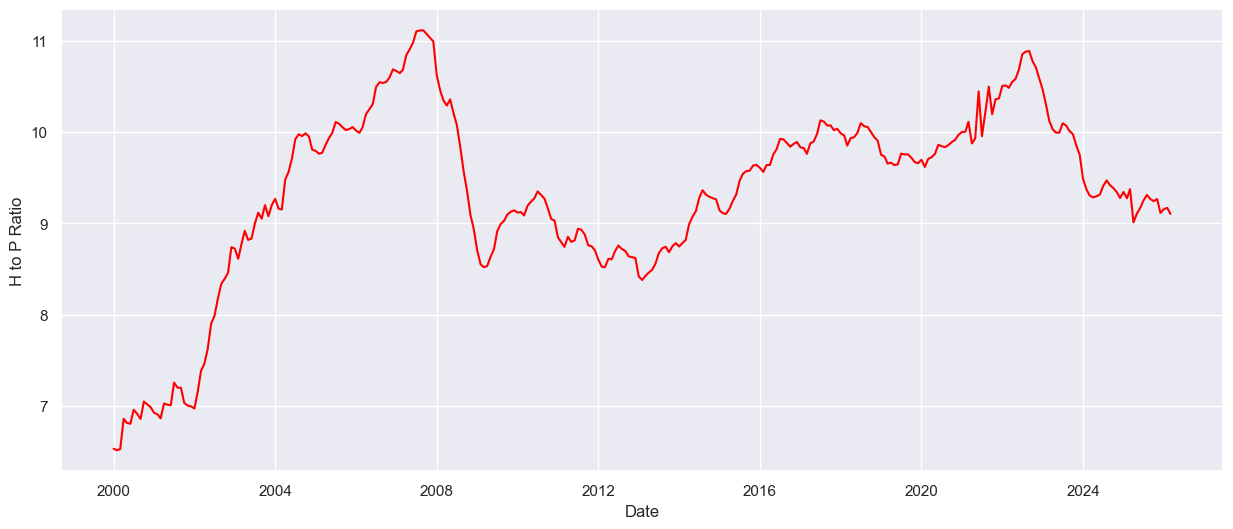

In [33]:
#Visualise ratio against time
plt.figure(figsize=(15,6))

sns.lineplot(data=final, x="Date", y="H to P Ratio", color = "red")



This initial graph looks as though it disproves our original claim and general feeling (and indeed follows the same pattern of the ONS graph except they use median prices and wages); it actually shows that average house prices relative to wages are at a decade low and also on a downward trend since 2023. This can be explained simply as these show both the average UK house price and net pay, the housing crisis many are feeling are situated around larger cities, especially London where most of the country's economic activity lies. The nature of a housing crisis also means there would be less houses sold, meaning the HPI, which looks only at the prices of sold housing, will tend to be less accurate and not fully represent the market (rather just the sales).Ialso believe this enhances the downward trend as the only houses that are realistically sold in high volume, will be the relatively very cheap housing, and the majority of housing that would've been sold at different more stable points in time are completely price gated to those who would usually buy them (young adults). Thus the downward trend is likely an oversight that the market would function as a continuous stream of buyers and sellers, neglecting the fact that the ceasing of purchased housing would affect the very metrics that are used to measure it.

With this discussion, we can now see the limitations of this project, in that the data of UK wide net yearly wages and housing prices can not even allude to the initial hypothesis. Instead as an extension we can narrow the data to the biggest culprit of the housing crisis, London, and recalculate the ratio to validate our previous claim. The pipeline itself is quite robust and can be a very useful tool to apply tax codes over multiple decades and compare to house prices of specific areas. However the factors that I believe are causing the data to not show the full picture seem to be shrouded in ambiguity or at least not available as official statistics. Perhaps better metrics could be acquired, not just looking at hard figures but polling those in the public, and the conjunction of the two will elucidate what is concretely felt by many not just in the UK but around the world. 